**1. Dataset Description & Schema Summary**

Data Source

The dataset used in this analysis is derived from the U.S. Consumer Product Safety Commission (CPSC) National Electronic Injury Surveillance System (NEISS). NEISS is a nationally representative surveillance system that collects data on consumer product-related injuries treated in U.S. emergency departments.

This dataset was filtered to include skiing- and snowboarding-related emergency department visits using relevant product codes (3283 for skiing and 5031 for snowboarding) and restricted to cases occurring between 2016 and 2024.

Unit of observation:
Each row in the dataset represents one emergency department injury case (one injury visit) involving skiing or snowboarding equipment:
One row = one emergency department case (injury visit).

Dataset Shape

Total Rows: 10,317

Total Columns: 28

This reflects 10,317 emergency department cases meeting the filtering criteria over the 2016–2024 time period.

Research question: How do skiing versus snowboarding injury patterns differ by age and sex, and what factors are associated with more severe outcomes (e.g., hospitalization)?

Key Variables Used in This Analysis:

The following variables were selected based on their relevance to the research question and are used throughout the exploratory analysis:

Age – Patient age in years at time of injury.

Sex – Biological sex recorded at the emergency department visit.

Sport – Indicator variable distinguishing skiing and snowboarding cases.

Diagnosis – Primary injury diagnosis code (mapped to descriptive labels such as sprain/strain, fracture, etc.).

Body_Part – Primary injured body region.

Disposition – Emergency department outcome (e.g., treated/released vs admitted or transferred), used as a proxy for injury severity.

Year – Year of treatment, used to evaluate temporal trends.

Weight – Sampling weight provided by NEISS for generating national estimates (acknowledged but not applied in unweighted exploratory counts).

Schema Summary

Below is a summary of the primary variables included in the dataset:

In [6]:
#Step 0: import libraries and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [7]:
#Step 1: load + initial inspection
path = "/Users/fchavez/Desktop/NEISS_V1_Comprehensive/neiss_snow_2016_2024_clean.csv"
df_raw = pd.read_csv(path)

#Quick inspection/create schema table
print("Shape:", df_raw.shape)
display(df_raw.head())

df_raw.info()

display(df_raw.describe(include="all"))

missing = df_raw.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

Shape: (10317, 28)


,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,Body_Part_2,Diagnosis_2,Other_Diagnosis_2,Disposition,Location,Fire_Involvement,Alcohol,Drug,Product_1,Product_2,Product_3,Narrative_1,Stratum,PSU,Weight,Year,Sport,Age_Group
0,160103172,2016-01-01,39,1,1,NaN,NaN,79,59,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,3283,0,0,39YOM INJ.RT.SIDE BUTTOCK WHEN SNOW SKIING AT ...,S,28,87.7206,2016,Skiing,36-40
1,160105047,2016-01-03,21,2,1,NaN,NaN,34,57,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,21YO F WAS SNOWBOARDING WHEN SHE FELL ONTO OUT...,L,89,72.8490,2016,Snowboarding,21-25
2,160106726,2016-01-01,25,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,25YOM SNOWBOARDING FELL ONTO R SH: AC SEP R/SH...,V,67,16.1154,2016,Snowboarding,21-25
3,160106842,2016-01-01,46,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,3283,0,0,46YOM D'LOC SHLDR- FELL SNOW SKIING,V,17,16.1154,2016,Skiing,46-50
4,160109852,2016-01-02,33,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,33YOM SNOWBOARDING FELL FLAT ONTO CLOSED SH ON...,V,67,16.1154,2016,Snowboarding,31-35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10317 entries, 0 to 10316
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CPSC_Case_Number   10317 non-null  int64  
 1   Treatment_Date     10317 non-null  object 
 2   Age                10317 non-null  int64  
 3   Sex                10317 non-null  int64  
 4   Race               10317 non-null  int64  
 5   Other_Race         234 non-null    object 
 6   Hispanic           7289 non-null   float64
 7   Body_Part          10317 non-null  int64  
 8   Diagnosis          10317 non-null  int64  
 9   Other_Diagnosis    1865 non-null   object 
 10  Body_Part_2        1293 non-null   float64
 11  Diagnosis_2        1293 non-null   float64
 12  Other_Diagnosis_2  336 non-null    object 
 13  Disposition        10317 non-null  int64  
 14  Location           10317 non-null  int64  
 15  Fire_Involvement   10317 non-null  int64  
 16  Alcohol            728

,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,Body_Part_2,Diagnosis_2,Other_Diagnosis_2,Disposition,Location,Fire_Involvement,Alcohol,Drug,Product_1,Product_2,Product_3,Narrative_1,Stratum,PSU,Weight,Year,Sport,Age_Group
count,1.031700e+04,10317,10317.000000,10317.000000,10317.000000,234,7289.000000,10317.000000,10317.000000,1865,1293.000000,1293.000000,336,10317.000000,10317.000000,10317.000000,7289.000000,7289.000000,10317.000000,10317.000000,10317.000000,10317,10317,10317.000000,10317.000000,10317.000000,10317,10317
unique,NaN,1350,NaN,NaN,NaN,12,NaN,NaN,NaN,379,NaN,NaN,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10290,5,NaN,NaN,NaN,2,19
top,NaN,2022-01-16,NaN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,PAIN,NaN,NaN,PAIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13 YOM FELL WHILE SNOWBOARDING. DX RADIUS FX,V,NaN,NaN,NaN,Skiing,11-15
freq,NaN,45,NaN,NaN,NaN,104,NaN,NaN,NaN,865,NaN,NaN,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,3094,NaN,NaN,NaN,5831,2217
mean,2.047170e+08,NaN,26.605796,1.356402,1.048851,NaN,1.683358,50.430455,60.441698,NaN,60.070379,61.283836,NaN,1.302413,8.234855,0.000291,0.004253,0.002607,4027.495396,84.596200,4.754774,NaN,NaN,48.277212,47.752047,2020.341088,NaN,NaN
std,2.612210e+07,NaN,16.321282,0.479364,0.887495,NaN,0.693706,22.553670,6.168864,NaN,23.931963,7.037759,NaN,0.954290,2.335515,0.029536,0.065081,0.050992,887.140904,496.721564,120.701806,NaN,NaN,27.314766,31.357172,2.601129,NaN,NaN
min,1.601032e+08,NaN,2.000000,0.000000,0.000000,NaN,0.000000,0.000000,41.000000,NaN,30.000000,51.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,374.000000,0.000000,0.000000,NaN,NaN,1.000000,4.505600,2016.000000,NaN,NaN
25%,1.803151e+08,NaN,14.000000,1.000000,1.000000,NaN,2.000000,33.000000,57.000000,NaN,34.000000,55.000000,NaN,1.000000,9.000000,0.000000,0.000000,0.000000,3283.000000,0.000000,0.000000,NaN,NaN,27.000000,16.182800,2018.000000,NaN,NaN
50%,2.101442e+08,NaN,22.000000,1.000000,1.000000,NaN,2.000000,35.000000,57.000000,NaN,75.000000,62.000000,NaN,1.000000,9.000000,0.000000,0.000000,0.000000,3283.000000,0.000000,0.000000,NaN,NaN,54.000000,55.441700,2021.000000,NaN,NaN
75%,2.301605e+08,NaN,34.000000,2.000000,1.000000,NaN,2.000000,75.000000,64.000000,NaN,79.000000,71.000000,NaN,1.000000,9.000000,0.000000,0.000000,0.000000,5031.000000,0.000000,0.000000,NaN,NaN,61.000000,76.821600,2023.000000,NaN,NaN


,missing_count
Other_Race,10083
Other_Diagnosis_2,9981
Body_Part_2,9024
Diagnosis_2,9024
Other_Diagnosis,8452
Alcohol,3028
Drug,3028
Hispanic,3028


**2. Data Cleaning & Preprocessing Steps**

The following ordered pipeline was used to prepare the dataset:

Step 1: Initial Inspection

The dataset was loaded using pd.read_csv() and inspected using:

df.shape

df.head()

df.info()

df.describe()

df.isna().sum()

This step confirmed the dataset structure and identified missing values.

In [8]:
#Start a cleaning pipeline copy
df = df_raw.copy()

In [10]:
#Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_", regex=False)
      .str.replace("-", "_", regex=False)
)
print(df.columns.tolist())

['CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race', 'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis', 'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition', 'Location', 'Fire_Involvement', 'Alcohol', 'Drug', 'Product_1', 'Product_2', 'Product_3', 'Narrative_1', 'Stratum', 'PSU', 'Weight', 'Year', 'Sport', 'Age_Group']


In [11]:
#Duplicate checks
print("Exact duplicate rows:", df.duplicated().sum())


#if there are duplicates, then run the following:
#df = df.drop_duplicates()
#df = df.drop_duplicates(subset=["CPSC_Case_Number"])

Exact duplicate rows: 0


In [12]:
#Duplicate case ids if they exist (to check for unique id duplicates)
id_col = "CPSC_Case_Number"
if id_col in df.columns:
    dup_ids = df[id_col].duplicated().sum()
    print(f"Duplicate {id_col} values:", dup_ids)
else:
    print(f"{id_col} not found in columns.")

Duplicate CPSC_Case_Number values: 0


In [14]:
#Age numeric + plausibility
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
invalid_age = (df["Age"] < 0) | (df["Age"] > 115)
print("Invalid ages:", invalid_age.sum())
df.loc[invalid_age, "Age"] = np.nan

#Weight numeric (NEISS weights)
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")
print("Missing Weight:", df["Weight"].isna().sum())

Invalid ages: 0
Missing Weight: 0


In [3]:
#sanity checks/value counts
cat_cols = [
    "Sex","Race","Hispanic","Body_Part","Diagnosis","Body_Part_2","Diagnosis_2",
    "Disposition","Location","Fire_Involvement","Alcohol","Drug",
    "Product_1","Product_2","Product_3","Sport","Age_Group","Year"
]

for col in cat_cols:
    print("\n" + "="*70)
    print(f"{col} (top 15):")
    display(df[col].value_counts(dropna=False).head(15))


Sex (top 15):


NameError: name 'df' is not defined

In [16]:
#missingness overview
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct[missing_pct > 0].to_frame("missing_pct"))

,missing_count
Other_Race,10083
Other_Diagnosis_2,9981
Body_Part_2,9024
Diagnosis_2,9024
Other_Diagnosis,8452
Alcohol,3028
Drug,3028
Hispanic,3028


,missing_pct
Other_Race,97.731899
Other_Diagnosis_2,96.743239
Body_Part_2,87.467287
Diagnosis_2,87.467287
Other_Diagnosis,81.923040
Alcohol,29.349617
Drug,29.349617
Hispanic,29.349617


In [22]:
#mapping diagnosis codes to diagnosis labels
diagnosis_map = {
    52: "Fracture",
    53: "Dislocation",
    55: "Internal injury",
    57: "Sprain/Strain",
    58: "Nerve damage",
    59: "Laceration",
    61: "Burn",
    62: "Internal organ injury",
    64: "Contusion/Abrasion",
    71: "Hematoma"
}

df["Diagnosis_Label"] = df["Diagnosis"].map(diagnosis_map)

In [17]:
#basic severity flag: admitted/transfer vs treated/released.
#this is a placeholder because NEISS disposition codes vary
df["severe_flag"] = df["Disposition"].isin([2, 4, 5, 6]).astype(int)

df["severe_flag"].value_counts(dropna=False)

severe_flag
0    9281
1    1036
Name: count, dtype: int64

In [25]:
#Step 3a

#Dataset shape
print("Dataset Shape (rows, columns):")
print(df_raw.shape)

#Preview first 5 rows
print("\nFirst 5 rows:")
display(df_raw.head())

#Column information and data types
print("\nDataset Info:")
df_raw.info()

#Summary statistics (numeric + categorical)
print("\nSummary Statistics:")
display(df_raw.describe(include="all"))

#Missingness overview
print("\nMissing Values (Count):")
missing_counts = df_raw.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0].to_frame("missing_count"))

print("\nMissing Values (%):")
missing_percent = (df_raw.isna().mean() * 100).sort_values(ascending=False)
display(missing_percent[missing_percent > 0].to_frame("missing_percent"))

#Value counts for key categorical variables
key_categoricals = ["Sport", "Sex", "Diagnosis", "Disposition"]

for col in key_categoricals:
    if col in df_raw.columns:
        print("\n" + "="*60)
        print(f"Value counts for {col}:")
        display(df_raw[col].value_counts(dropna=False))

Dataset Shape (rows, columns):
(10317, 28)

First 5 rows:


,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,Body_Part_2,Diagnosis_2,Other_Diagnosis_2,Disposition,Location,Fire_Involvement,Alcohol,Drug,Product_1,Product_2,Product_3,Narrative_1,Stratum,PSU,Weight,Year,Sport,Age_Group
0,160103172,2016-01-01,39,1,1,NaN,NaN,79,59,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,3283,0,0,39YOM INJ.RT.SIDE BUTTOCK WHEN SNOW SKIING AT ...,S,28,87.7206,2016,Skiing,36-40
1,160105047,2016-01-03,21,2,1,NaN,NaN,34,57,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,21YO F WAS SNOWBOARDING WHEN SHE FELL ONTO OUT...,L,89,72.8490,2016,Snowboarding,21-25
2,160106726,2016-01-01,25,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,25YOM SNOWBOARDING FELL ONTO R SH: AC SEP R/SH...,V,67,16.1154,2016,Snowboarding,21-25
3,160106842,2016-01-01,46,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,3283,0,0,46YOM D'LOC SHLDR- FELL SNOW SKIING,V,17,16.1154,2016,Skiing,46-50
4,160109852,2016-01-02,33,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,33YOM SNOWBOARDING FELL FLAT ONTO CLOSED SH ON...,V,67,16.1154,2016,Snowboarding,31-35



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10317 entries, 0 to 10316
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CPSC_Case_Number   10317 non-null  int64  
 1   Treatment_Date     10317 non-null  object 
 2   Age                10317 non-null  int64  
 3   Sex                10317 non-null  int64  
 4   Race               10317 non-null  int64  
 5   Other_Race         234 non-null    object 
 6   Hispanic           7289 non-null   float64
 7   Body_Part          10317 non-null  int64  
 8   Diagnosis          10317 non-null  int64  
 9   Other_Diagnosis    1865 non-null   object 
 10  Body_Part_2        1293 non-null   float64
 11  Diagnosis_2        1293 non-null   float64
 12  Other_Diagnosis_2  336 non-null    object 
 13  Disposition        10317 non-null  int64  
 14  Location           10317 non-null  int64  
 15  Fire_Involvement   10317 non-null  int64  
 16  Alcohol

,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,Body_Part_2,Diagnosis_2,Other_Diagnosis_2,Disposition,Location,Fire_Involvement,Alcohol,Drug,Product_1,Product_2,Product_3,Narrative_1,Stratum,PSU,Weight,Year,Sport,Age_Group
count,1.031700e+04,10317,10317.000000,10317.000000,10317.000000,234,7289.000000,10317.000000,10317.000000,1865,1293.000000,1293.000000,336,10317.000000,10317.000000,10317.000000,7289.000000,7289.000000,10317.000000,10317.000000,10317.000000,10317,10317,10317.000000,10317.000000,10317.000000,10317,10317
unique,NaN,1350,NaN,NaN,NaN,12,NaN,NaN,NaN,379,NaN,NaN,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10290,5,NaN,NaN,NaN,2,19
top,NaN,2022-01-16,NaN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,PAIN,NaN,NaN,PAIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13 YOM FELL WHILE SNOWBOARDING. DX RADIUS FX,V,NaN,NaN,NaN,Skiing,11-15
freq,NaN,45,NaN,NaN,NaN,104,NaN,NaN,NaN,865,NaN,NaN,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,3094,NaN,NaN,NaN,5831,2217
mean,2.047170e+08,NaN,26.605796,1.356402,1.048851,NaN,1.683358,50.430455,60.441698,NaN,60.070379,61.283836,NaN,1.302413,8.234855,0.000291,0.004253,0.002607,4027.495396,84.596200,4.754774,NaN,NaN,48.277212,47.752047,2020.341088,NaN,NaN
std,2.612210e+07,NaN,16.321282,0.479364,0.887495,NaN,0.693706,22.553670,6.168864,NaN,23.931963,7.037759,NaN,0.954290,2.335515,0.029536,0.065081,0.050992,887.140904,496.721564,120.701806,NaN,NaN,27.314766,31.357172,2.601129,NaN,NaN
min,1.601032e+08,NaN,2.000000,0.000000,0.000000,NaN,0.000000,0.000000,41.000000,NaN,30.000000,51.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,374.000000,0.000000,0.000000,NaN,NaN,1.000000,4.505600,2016.000000,NaN,NaN
25%,1.803151e+08,NaN,14.000000,1.000000,1.000000,NaN,2.000000,33.000000,57.000000,NaN,34.000000,55.000000,NaN,1.000000,9.000000,0.000000,0.000000,0.000000,3283.000000,0.000000,0.000000,NaN,NaN,27.000000,16.182800,2018.000000,NaN,NaN
50%,2.101442e+08,NaN,22.000000,1.000000,1.000000,NaN,2.000000,35.000000,57.000000,NaN,75.000000,62.000000,NaN,1.000000,9.000000,0.000000,0.000000,0.000000,3283.000000,0.000000,0.000000,NaN,NaN,54.000000,55.441700,2021.000000,NaN,NaN
75%,2.301605e+08,NaN,34.000000,2.000000,1.000000,NaN,2.000000,75.000000,64.000000,NaN,79.000000,71.000000,NaN,1.000000,9.000000,0.000000,0.000000,0.000000,5031.000000,0.000000,0.000000,NaN,NaN,61.000000,76.821600,2023.000000,NaN,NaN



Missing Values (Count):


...

Sex
1    6636
2    3679
0       2
Name: count, dtype: int64


Value counts for Diagnosis:


Diagnosis
57    3429
71    1865
64    1715
52     887
62     841
53     717
59     346
55     334
58      62
61      50
60      18
47      15
68       7
56       6
73       6
74       5
72       4
54       3
63       3
50       1
51       1
66       1
41       1
Name: count, dtype: int64


Value counts for Disposition:


Disposition
1    9281
4     775
2     119
6     108
5      34
Name: count, dtype: int64

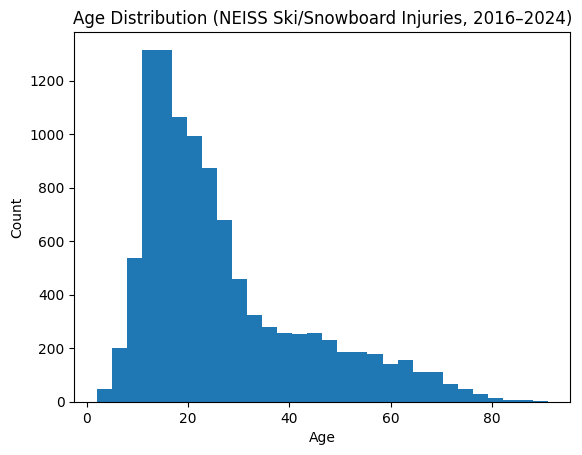

In [18]:
#3b: EDA Visuals 
#age distribution
plt.figure()
df["Age"].dropna().plot(kind="hist", bins=30)
plt.title("Age Distribution (NEISS Ski/Snowboard Injuries, 2016–2024)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution of skiing and snowboarding injuries is right-skewed, with the highest concentration of injuries occurring among adolescents and young adults, particularly between approximately 10–25 years of age. Injury counts decline steadily after early adulthood, though cases remain present across all age groups up to age 90. This suggests that younger individuals may engage in these sports at higher rates or exhibit greater risk-taking behavior, making age an important demographic factor for further modeling and injury prevention analysis.

<Figure size 640x480 with 0 Axes>

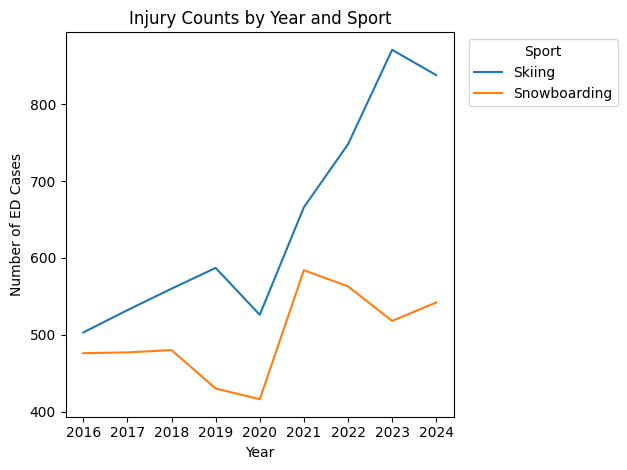

In [19]:
#injuries over time by sport (counts)
counts = df.groupby(["Year", "Sport"]).size().unstack("Sport").fillna(0)

plt.figure()
counts.plot()
plt.title("Injury Counts by Year and Sport")
plt.xlabel("Year")
plt.ylabel("Number of ED Cases")
plt.legend(title="Sport", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Injury counts for skiing show a steady increase from 2016 through 2019, a noticeable decline in 2020, and a sharp rebound from 2021 onward, peaking around 2023 before slightly declining in 2024. Snowboarding follows a similar pattern, with a drop in 2020 and recovery afterward, though at consistently lower case counts than skiing. The dip in 2020 likely reflects reduced participation during the COVID-19 pandemic rather than a true decline in injury risk. Overall, skiing consistently accounts for a greater number of emergency department visits compared to snowboarding during the study period.

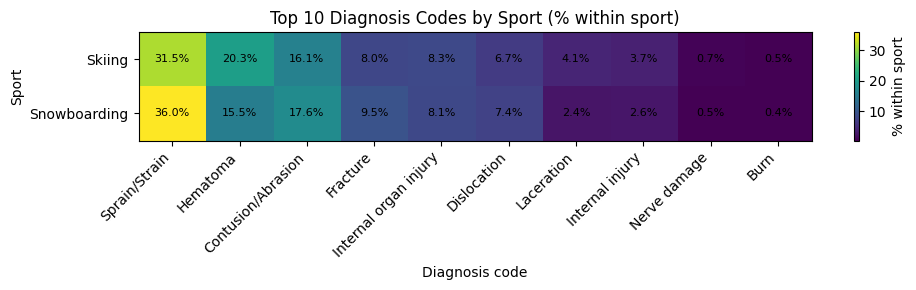

In [24]:
import matplotlib.pyplot as plt

#top diagnoses overall
top_n = 10
top_diag = df["Diagnosis_Label"].value_counts().head(top_n).index

ct = pd.crosstab(df["Sport"], df["Diagnosis_Label"])[top_diag]
prop = ct.div(ct.sum(axis=1), axis=0) * 100  # percent within sport

plt.figure(figsize=(10, 3))
plt.imshow(prop.values, aspect="auto")
plt.xticks(range(len(prop.columns)), prop.columns, rotation=45, ha="right")
plt.yticks(range(len(prop.index)), prop.index)
plt.colorbar(label="% within sport")
plt.title(f"Top {top_n} Diagnosis Codes by Sport (% within sport)")
plt.xlabel("Diagnosis code")
plt.ylabel("Sport")

#annotate cells
for i in range(prop.shape[0]):
    for j in range(prop.shape[1]):
        plt.text(j, i, f"{prop.iloc[i, j]:.1f}%", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Sprain/strain injuries represent the largest proportion of injuries in both skiing (31.5%) and snowboarding (36.0%), indicating that soft tissue injuries are the most common outcome in these sports. Snowboarding shows a slightly higher proportion of fractures (9.5%) compared to skiing (8.0%), while skiing shows higher proportions of hematomas and lacerations. Contusions/abrasions are also prominent in both sports. These differences suggest potential variation in injury mechanisms between skiing and snowboarding, supporting the research question that injury patterns differ by sport type.

***Step 4: Ethical, De-identification, & Data Quality Concerns***

**De-identification**

The NEISS dataset is publicly available and de-identified. It does not contain direct personal identifiers such as names, addresses, or Social Security numbers. Each case is represented only by a numeric case identifier (CPSC_Case_Number), which cannot be linked back to individual patients using public data.

**Quasi-identifiers**

Although the dataset contains demographic variables such as age, race, ethnicity, and treatment date, these fields are generalized and do not contain precise geographic identifiers. To further reduce re-identification risk, analyses are conducted at aggregated levels (e.g., age distribution, yearly counts) rather than reporting individual-level records.

**Sampling and Representativeness**

NEISS is a stratified probability sample of U.S. hospitals and includes sampling weights (Weight, Stratum, PSU) to generate national estimates. The exploratory analysis conducted here uses unweighted case counts, which reflect the sampled emergency departments rather than true national incidence. As such, findings describe patterns within the observed dataset and should not be interpreted as exact national injury totals without applying survey weights.

**Missing Data**

Certain variables contain missing values, particularly secondary injury fields (Body_Part_2, Diagnosis_2) and ethnicity indicators. Missingness in secondary injury variables is likely structural, as secondary injuries are recorded only when present. No imputation was performed to avoid introducing artificial information into the dataset.

**Data Limitations**

This dataset captures only injuries treated in emergency departments. Less severe injuries treated at urgent care clinics or not treated medically are not included, potentially biasing the data toward more serious cases. Additionally, diagnosis codes are recorded using standardized categories, which may limit clinical granularity. Because the data are observational, causal conclusions about injury mechanisms or prevention strategies cannot be definitively established.